# Multiqubit phase-gate optimization with autodiff

<span style="font-variant: small-caps;">Simphony</span> can be used not only to simulate driven spin dynamics, but also to **optimize control pulses with automatic differentiation**.

In this example notebook, we build a **multiqubit phase-gate** workflow on top of a predefined NV-center model.

The notebook proceeds in three steps:
1. Build the physical model and define the target gate.
2. Benchmark a simple rectangle pulse.
3. Optimize a piecewise-constant complex envelope with autodiff.

## Import the packages

We begin by importing <span style="font-variant: small-caps;">Simphony</span> together with the numerical and plotting tools used throughout the notebook:

In [ ]:
import numpy as np

import simphony
simphony.Config.set_platform('gpu')
simphony.Config.set_autodiff_mode(True)
simphony.Config.set_matplotlib_format('retina')

from jax import value_and_grad
import jax.numpy as jnp

from qiskit import QuantumCircuit
from qiskit.circuit.library import RXGate

from scipy.optimize import minimize

from IPython.display import clear_output, display
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator

seed = 42
np.random.seed(seed)

## Model
We start from a **predefined NV model** containing **one electron** spin, **one $^{14}\text{N}$** spin, and **two** selected **$^{13}\text{C}$** spins. The rotating frame is chosen so the target unitary is evaluated in a convenient computational basis (see more details in the API documentation of the `RotatingFrameSetter`):


In [2]:
model = simphony.default_nv_model(
    nitrogen_isotope=14,
    static_field_strength=0.05,
    carbon_atom_indices=[(1, 1, 1, 0), (2, -3, 4, 1)],
    rotating_frame=simphony.RotatingFrameSetter(
        rest_electron_spin_state='0',
        rest_nuclear_spin_state='1',
    ),
)

Inspecting the model helps confirm the energy-level structure and the spin-labels used later in the notebook:

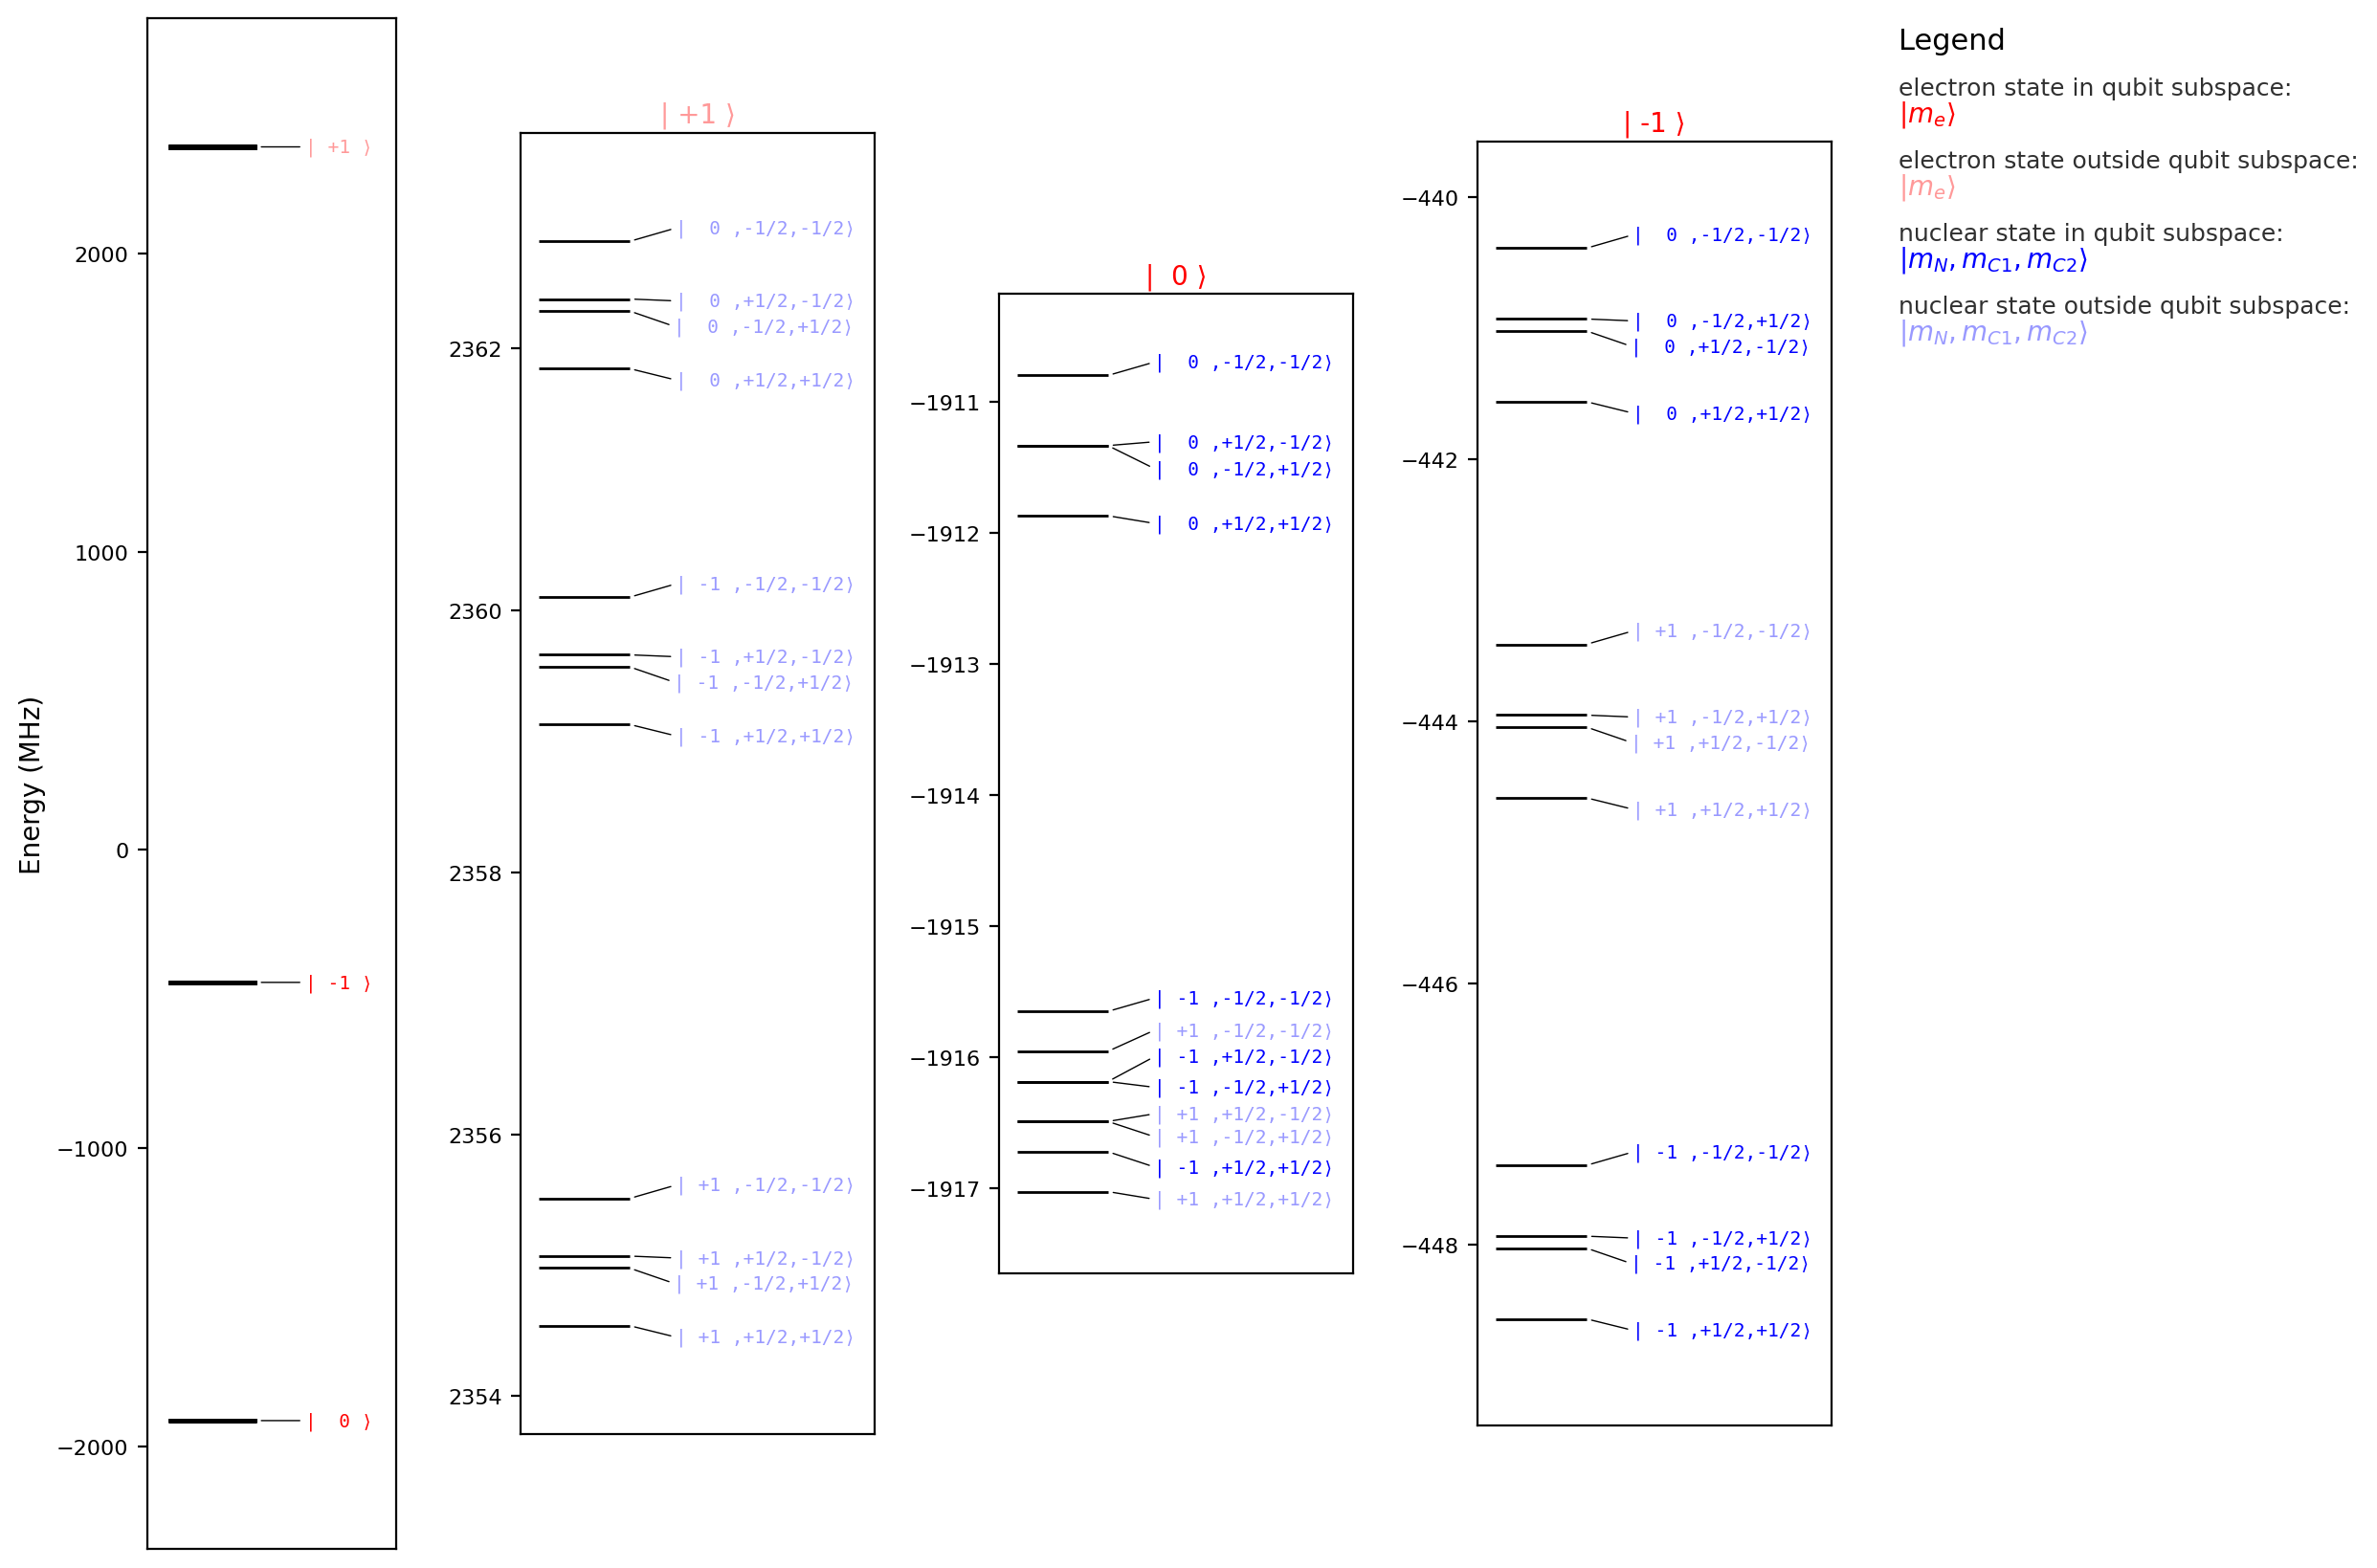

['e', 'N', 'C1', 'C2']

In [3]:
model.plot_levels()
model.spin_names

## Phase-gate

The phase gate is implemented with a **weak electron-spin drive**. The pulse rotates the electron spin by $2\pi$ only when the nuclear spins are in their qubit state $\ket{1}$ that results an addition $\pi$ phase for that computational basis state. In this model, that configuration corresponds to the quantum numbers $m_I=-1$ for the nitrogen spin and $m_I=1/2$ for the two carbon spins:

In [4]:
rest_quantum_nums = {'N': -1, 'C1': 1 / 2, 'C2': 1 / 2}
frequency = model.splitting_qubit('e', rest_quantum_nums=rest_quantum_nums)
frequency

1468.1596093930461

The target operation is written below as a **three-controlled $\text{RX}(2\pi)$ gate**. On the nuclear-spin subspace, with the electron fixed as an ancilla, this is equivalent to a **phase gate**:

In [5]:
qc = QuantumCircuit(4)
angle = 2 * np.pi
qc.append(RXGate(angle).control(num_ctrl_qubits=3), [1, 2, 3, 0])
qc.draw()

┌────────┐
q_0: ┤ Rx(2π) ├
     └───┬────┘
q_1: ────■─────
         │     
q_2: ────■─────
         │     
q_3: ────■─────

Since the electron is used as an ancilla prepared in $\ket{0}$, the relevant figure of merit to optimize is the average gate fidelity on the nuclear-spin subspace with `ancilla_state={'e': '0'}` (see below).

## Rectangular pulse baseline

Before moving to the piecewise-constant envelope optimization, we benchmark the single **rectangular-envelope pulse**. The pulse frequency is set to be resonant with the electron splitting when the nuclear spins are in the qubit state $\ket{1}$:

In [6]:
def gate_error_rectangle(duration, model, qc):
    rest_quantum_nums = {'N': -1, 'C1': 1 / 2, 'C2': 1 / 2}
    frequency = model.splitting_qubit('e', rest_quantum_nums=rest_quantum_nums)
    angle = 2 * np.pi
    period_time = 2 * np.pi / angle * duration
    amplitude = model.rabi_amplitude_qubit(
        driving_field_name='MW_x',
        period_time=period_time,
        spin_name='e',
        rest_quantum_nums=rest_quantum_nums,
    )

    model.remove_all_pulses()
    model.driving_field('MW_x').add_rectangle_pulse(
        amplitude=amplitude,
        frequency=frequency,
        phase=0,
        duration=duration,
    )
    result = model.simulate_time_evolution(n_eval=2)
    result.ideal = qc
    return 1 - result.average_gate_fidelity(ancilla_state={'e': '0'})

We now scan the pulse duration over a broad range and compute the corresponding gate error:

In [ ]:
durations = np.logspace(0, np.log10(2500), 25)
gate_errors = []
for idx, duration in enumerate(durations):
    gate_errors.append(gate_error_rectangle(duration, model, qc))
    print(f'{idx + 1}/{len(durations)}', end=' ')
gate_errors = np.array(gate_errors)

The resulting duration dependence is shown below:

In [ ]:
plt.plot(durations, gate_errors, '.-')
plt.xlabel('Pulse duration [$\mu$s]')
plt.ylabel('Gate error')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.show()

The plot shows that a rectangular pulse reaches **low gate error only for relatively long pulse durations**, typically above about 1000 $\mu$s in this setup.

## Optimization helpers

To optimize a **pulse with a piecewise-constant envelope** using autodiff, we use a **bounded parameterization**. The pulse-segment amplitudes are mapped from a finite interval to an unconstrained space, optimized there, and then mapped back before the simulation is evaluated.

In [ ]:
def bound_to_free(params, bounds):
    def two_sided_bound(x, x_min, x_max):
        scaled_x = 2 * (x - x_min) / (x_max - x_min) - 1
        return jnp.arctanh(scaled_x)

    def two_sided_bound_inv(y, x_min, x_max):
        scaled_y = jnp.tanh(y)
        return (scaled_y + 1) / 2 * (x_max - x_min) + x_min

    free_params = []
    bound_fns = []

    for param, (lower, upper) in zip(params, bounds):
        free_params.append(two_sided_bound(param, lower, upper))
        bound_fns.append(lambda y, lb=lower, ub=upper: two_sided_bound_inv(y, lb, ub))

    def free_to_bound(values):
        return jnp.array([fn(value) for fn, value in zip(bound_fns, values)])

    return jnp.array(free_params), free_to_bound


def optimize_pulse(gate_error, model, init_parameters, bounds, maxiter=100):
    free_parameters, free_to_bound = bound_to_free(init_parameters, bounds)

    def gate_error_free(free_parameters, model):
        return gate_error(free_to_bound(free_parameters), model)

    gate_error_free_value_and_grad = value_and_grad(gate_error_free)
    init_value = gate_error(init_parameters, model)
    opt_result = {'value': [init_value], 'parameters': [init_parameters], 'grad': [jnp.nan]}

    fig, ax = plt.subplots(1, 1)
    ax.set_xlabel('Number of steps')
    ax.set_ylabel('Gate error')
    ax.set_yscale('log')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(visible=True)
    line, = ax.plot(opt_result['value'], 'o-')
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([0])
    display(fig)

    state = {'current': None}

    def objective(free_parameters, model):
        value, grad = gate_error_free_value_and_grad(free_parameters, model)
        parameters = free_to_bound(free_parameters)
        state['current'] = (value, parameters, grad)
        return value, grad

    def refresh_plot(values):
        line.set_data(range(len(values)), values)
        if len(values) == 1:
            ax.set_xlim(-0.5, 0.5)
            ax.set_xticks([0])
        else:
            ax.set_xlim(-0.5, len(values) - 0.5)
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax.relim()
            ax.autoscale_view(scalex=False, scaley=True)
        clear_output(wait=True)
        display(fig)

    def callback(_):
        value, parameters, grad = state['current']
        opt_result['value'].append(value)
        opt_result['parameters'].append(parameters)
        opt_result['grad'].append(grad)
        refresh_plot(opt_result['value'])

    res = minimize(
        fun=objective,
        args=model,
        x0=free_parameters,
        jac=True,
        method='L-BFGS-B',
        options={'gtol': 1e-12, 'ftol': 1e-12, 'maxiter': maxiter},
        callback=callback,
    )
    opt_result['res'] = res
    plt.close(fig)
    return opt_result

To set the pulse amplitude scale, we define an upper bound based on a maximum allowed electron-spin Rabi frequency:

In [ ]:
max_rabi_frequency = 500 # MHz
max_duration = 0.5 / max_rabi_frequency
max_amplitude = model.rabi_amplitude_qubit(
    driving_field_name='MW_x',
    period_time=2 * max_duration,
    spin_name='e',
)

## Piecewise-constant pulse-envelope optimization

We now switch from a single rectangular-envelope pulse to a **piecewise-constant complex envelope**. The pulse is represented by `n` complex samples with a fixed time step `dt`, and the real and imaginary parts are optimized as independent parameters:

In [ ]:
frequency = model.splitting_qubit('e', rest_quantum_nums={'N': -1, 'C1': 1 / 2, 'C2': 1 / 2})

def gate_error_discrete(parameters, model, n_shots=1, n_split=101):
    samples = jnp.array(parameters[0::2]) + 1j * jnp.array(parameters[1::2])

    model.remove_all_pulses()
    model.driving_field('MW_x').add_discrete_pulse(
        samples=samples,
        frequency=frequency,
        dt=dt,
    )

    result = model.simulate_time_evolution(n_eval=2, n_shots=n_shots, n_split=n_split)
    result.ideal = qc
    return 1 - result.average_gate_fidelity(ancilla_state={'e': '0'})

The total pulse duration is set to $125\,\mu\mathrm{s}$ and divided into **25 equal segments**, resulting in 50 optimized parameters. The optimization is initialized with a **randomized complex pulse**. The initial segment amplitudes are sampled around the Rabi amplitude of the corresponding rectangular pulse, while the phases are chosen uniformly at random:

In [ ]:
duration = 125
n = 25

rest_quantum_nums = {'N': -1, 'C1': 1 / 2, 'C2': 1 / 2}
amplitude = model.rabi_amplitude_qubit(
    driving_field_name='MW_x',
    period_time=duration,
    spin_name='e',
    rest_quantum_nums=rest_quantum_nums,
)
dt = duration / n

samples = []
for _ in range(n):
    a = amplitude * np.random.uniform(0.5, 1.5)
    phi = np.random.uniform(0, 2 * np.pi)
    samples.append(a * np.cos(phi))
    samples.append(a * np.sin(phi))

params = jnp.array(samples)
bounds = [(-max_amplitude, max_amplitude) for _ in range(2 * n)]

With the model, target gate, objective, and initialization in place, we can run the pulse optimization. The plot is updated after each optimization step:

In [ ]:
opt_result = optimize_pulse(
    gate_error_discrete,
    model,
    params,
    bounds,
    maxiter=100,
)

The **final gate fidelity exceeds $99.9\%$**, which is a remarkably good result, especially considering that a **rectangular pulse** of the same duration achieves a fidelity of only **around $90\%$**:

In [ ]:
final_gate_error = opt_result['value'][-1]
1 - final_gate_error

The resulting optimized pulse sequence is shown below:

In [ ]:
model.driving_field('MW_x').plot_pulses(function='complex_envelope')

**Note:** This optimization process is conceptually similar to the **Gradient Ascent Pulse Engineering (GRAPE)** method, but it **does not rely on the rotating wave approximation (RWA)** and explicitly accounts for **leakage** outside the computational subspace.